# Health analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Läser in data
df = pd.read_csv("../data/health_study_dataset.csv")

# Kolumner att analysera
columns = ['age', 'weight', 'height', 'systolic_bp', 'cholesterol']

# Beräkna med pandas
stats_df = pd.DataFrame({
    'Medel': df[columns].mean(),
    'Median': df[columns].median(),
    'Min': df[columns].min(),
    'Max': df[columns].max()
}).round(2)

# Fin utskrift
stats_df



,Medel,Median,Min,Max
age,49.43,50.00,18.0,90.00
weight,73.41,73.20,33.7,114.40
height,171.85,171.35,144.4,200.40
systolic_bp,149.18,149.40,106.8,185.90
cholesterol,4.93,4.97,2.5,7.88


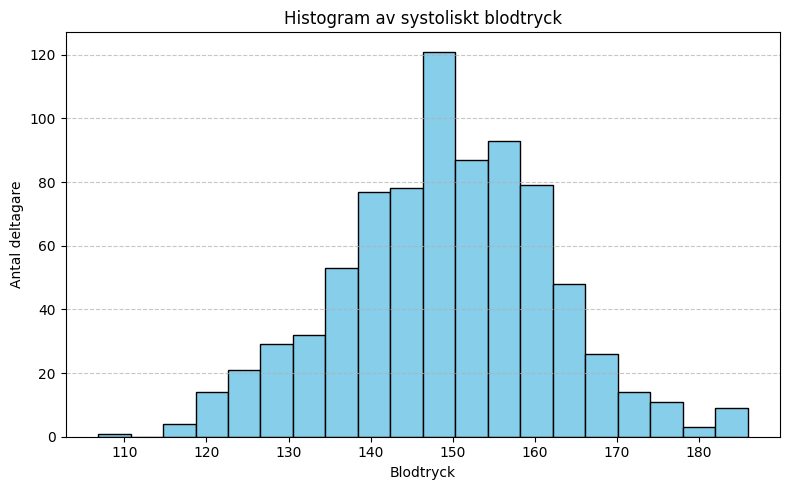

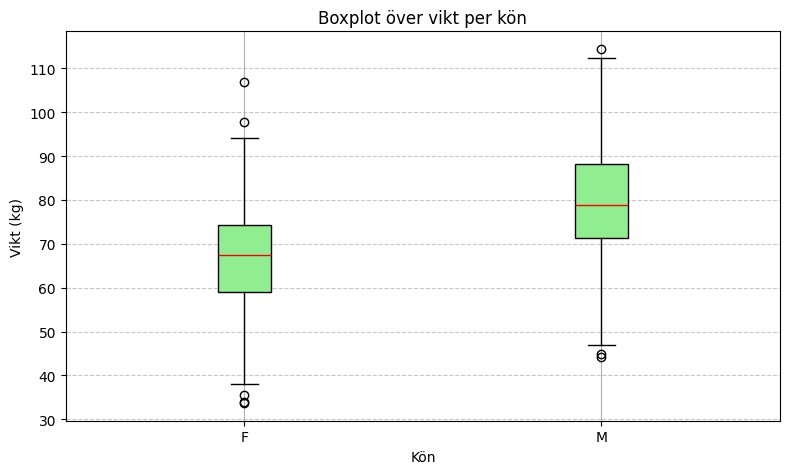

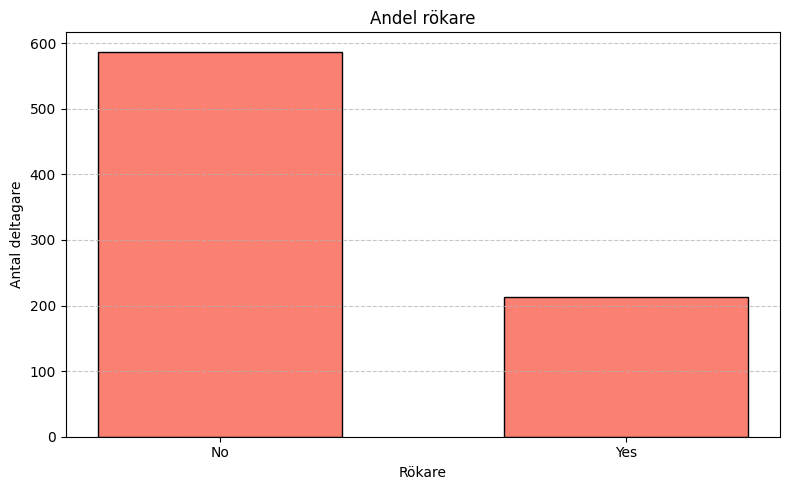

In [7]:
#Ritar de olika graferna

# Histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['systolic_bp'].dropna(), bins=20, color='skyblue', edgecolor='black')
ax.set_title("Histogram av systoliskt blodtryck")
ax.set_xlabel("Blodtryck")
ax.set_ylabel("Antal deltagare")
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
df_box = df[['weight', 'sex']].dropna()
df_box.boxplot(column= 'weight', by='sex', ax=ax, patch_artist=True, 
               boxprops=dict(facecolor='lightgreen', color='black'),
               medianprops=dict(color='red'),  
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'))
ax.set_title("Boxplot över vikt per kön")
ax.set_xlabel("Kön")
ax.set_ylabel("Vikt (kg)")
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.suptitle("")
plt.tight_layout()
plt.show()

# Bar
fig, ax = plt.subplots(figsize=(8, 5))
smoker_clean = df['smoker'].astype(str).str.strip().str.lower().map({'yes': 'Yes', 'no': 'No'})
smoker_counts = smoker_clean.value_counts().sort_index()
ax.bar(smoker_counts.index, smoker_counts.values, color='salmon', edgecolor='black',  width=0.6)
ax.set_title("Andel rökare")
ax.set_xlabel("Rökare")
ax.set_ylabel("Antal deltagare")
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Verklig andel & simulerad andel sjuka


p_sick = df['disease'].sum()       # Verklig andel med sjukdom
total = len(df['disease'])        # Totalt antal observationer
obs_proportion = p_sick / total   # Beräknar andel med sjukdom
print(f"Verklig andel med sjukdom: {obs_proportion:.3f}")

np.random.seed(42) 
simulated = np.random.binomial(1, obs_proportion, 1000)   # Simulation m 1000 personer
part_simulated = simulated.sum() / len(simulated)         # Beräknar andelen i simuleringen
print(f"Simulerad andel med sjukdom (1000 personer): {part_simulated:.3f}")


Verklig andel med sjukdom: 0.059
Simulerad andel med sjukdom (1000 personer): 0.056


In [4]:
# Konfidensintervall för systolic_bp

bp = df['systolic_bp'].dropna()
n = len(bp)                         # Observationer i datasetet
mean_bp = bp.mean()                 # Beräknar medelvärdet av systoliskt blodtryck
std_bp = bp.std(ddof=1)             # Beräknar standardavvikelsen (ddof=1 för stickprov)

alpha = 0.05                        # Signifikansnivå
t_crit = stats.t.ppf(1 - alpha / 2, df = n - 1)
se = std_bp / np.sqrt(n)            # Standardfel
ci_lower = mean_bp - t_crit * se    # Nedre gräns 
ci_upper = mean_bp + t_crit * se    # Övre gräns

print(f"T-baserat 95% CI för medelvärde systolic_bp: {ci_lower:.2f} — {ci_upper:.2f}")

T-baserat 95% CI för medelvärde systolic_bp: 148.29 — 150.07


In [8]:
# Hypotestesting (welch)
df['smoker'] = df['smoker'].str.strip().str.lower()
df_clean = df[['systolic_bp', 'smoker']].dropna()


# Dela upp grupperna
bp_smokers = df_clean[df_clean['smoker'] == 'yes']['systolic_bp']
bp_nonsmokers = df_clean[df_clean['smoker'] == 'no']['systolic_bp']

# Kontrollera antal observationer
print("Antal rökare:", len(bp_smokers))
print("Antal icke-rökare:", len(bp_nonsmokers))

t_stat, p_value = stats.ttest_ind(bp_smokers, bp_nonsmokers, equal_var=False)

# Visa resultat
print(f"\nT-värde: {t_stat:.4f}")
print(f"P-värde: {p_value:.4f}")


if p_value < 0.05:
    print("Skillnaden mellan grupperna är statistiskt signifikant.")
else:
    print("Ingen statistiskt signifikant skillnad mellan grupperna.")

Antal rökare: 213
Antal icke-rökare: 587

T-värde: 0.4503
P-värde: 0.6527
Ingen statistiskt signifikant skillnad mellan grupperna.




Vi testade hypotesen att rökare har högre medelvärde av systoliskt blodtryck än icke-rökare med Welch t-test.  
Eftersom p-värdet är större än 0.05 finns ingen statistiskt signifikant skillnad mellan grupperna.  
Alltså visar detta dataset att rökare inte har signifikant högre blodtryck än icke-rökare.


Här nedan kan man se hur test resultatet ser ut i ett histogram.

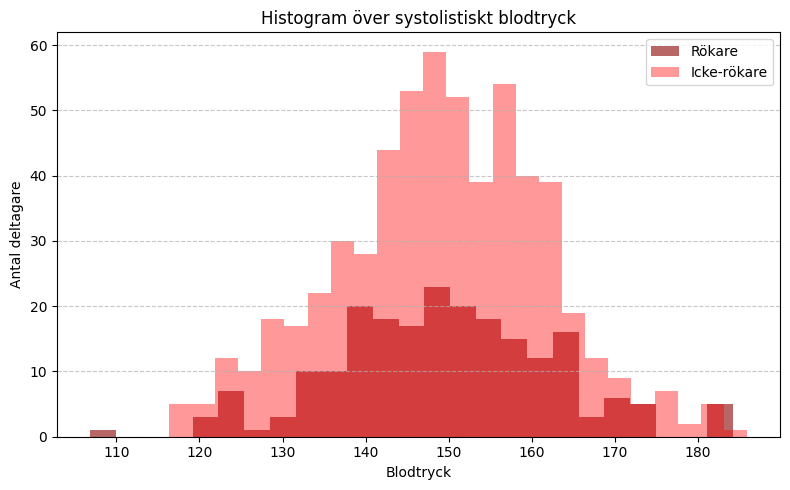

In [6]:
# Histogram för systoliskt blodtryck – rökare vs icke-rökare
fig, ax = plt.subplots(figsize=(8, 5))

# Skapar två histogram som ritas ovanpå varandra
ax.hist(bp_smokers, bins=25, alpha=0.6, label='Rökare', color='darkred')
ax.hist(bp_nonsmokers, bins=25, alpha=0.4, label='Icke-rökare', color='red')

# Sätter titel, label och grid
ax.set_title("Histogram över systolistiskt blodtryck")
ax.set_xlabel("Blodtryck")
ax.set_ylabel("Antal deltagare")
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Visar rutan med beskrivning
ax.legend()

plt.tight_layout()
plt.show()